# Context

<p1 size=3 color="black" style="font-family:TimesNewRoman">
Thera Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

As a Data scientist at Thera Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.</p>
  
    
**Motivation : To understand Logistic regression  and Decision tree and explore this algorthims using Sklearn, Statmodel,  Roc-Auc Curve,Precision Curve,Sequential feature selection, hyperparamter tuning Decision tress  and post pruning Decision trees**
  

## Problem

    
- To predict whether a liability customer will buy a personal loan or not.
- Which variables are most significant.
- Which segment of customers should be targeted more.
- Does Age have any impact of customer buying loan?
- Do people with less income borrow loans .?


# Libraries

In [1]:
!pip install zipcodes

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\CHUKA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\CHUKA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:

import scipy.stats as stats 
import pandas as pd
import numpy as np
import zipcodes as zcode 

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings

import statsmodels.api as sm
from sklearn.model_selection import train_test_split 

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import metrics
#AUC ROC curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier

pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_colwidth',400)
pd.set_option('display.float_format', lambda x: '%.5f' % x) 
warnings.filterwarnings('ignore') 
plt.style.use('ggplot')


# Read and Understand data

In [4]:

df=pd.read_csv(r"C:\Users\CHUKA\Desktop\persona_loan\Bank_Personal_Loan_Modelling.csv")
df_loan=df.copy()
print(f'There are {df_loan.shape[0]} rows and {df_loan.shape[1]} columns') 

There are 5000 rows and 14 columns


In [5]:
df_loan.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.60000,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.50000,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.00000,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.70000,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.00000,2,0,0,0,0,0,1


In [6]:
df_loan.tail()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.90000,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.40000,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.30000,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.50000,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.80000,1,0,0,0,0,1,1


In [7]:

print ("Rows     : " , df_loan.shape[0])  
print ("Columns  : " , df_loan.shape[1]) 
print ("#"*40,"\n","Features : \n\n", df_loan.columns.tolist()) 
print ("#"*40,"\nMissing values :\n\n", df_loan.isnull().sum().sort_values(ascending=False))
print( "#"*40,"\nPercent of missing :\n\n", round(df_loan.isna().sum() / df_loan.isna().count() * 100, 2)) 
print ("#"*40,"\nUnique values :  \n\n", df_loan.nunique())  


Rows     :  5000
Columns  :  14
######################################## 
 Features : 

 ['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
######################################## 
Missing values :

 ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64
######################################## 
Percent of missing :

 ID                   0.00000
Age                  0.00000
Experience           0.00000
Income               0.00000
ZIP Code             0.00000
Family               0.00000
CCAvg                0.00000
Education            0.00000
Mortgage             0.00000
Pers

In [8]:
df_loan.nunique()

ID                    5000
Age                     45
Experience              47
Income                 162
ZIP Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal Loan            2
Securities Account       2
CD Account               2
Online                   2
CreditCard               2
dtype: int64

In [9]:
df_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


**There are no missing values in the dataset.  All the columns are numerical here. `Personal loan` is target variable.  Zipcode,Family,Education,Securities Account,CD_account,online,Credit card are all categorical variables.**

In [10]:
df_loan.sample(10)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
2317,2318,31,5,129,95814,3,5.90000,3,319,1,1,1,0,1
3642,3643,55,29,21,92704,4,0.70000,3,0,0,1,0,1,0
4005,4006,56,32,32,95827,2,0.80000,1,79,0,1,0,1,0
3603,3604,51,25,45,92407,4,0.10000,1,0,0,0,0,1,1
3994,3995,42,18,88,92675,4,0.80000,1,0,0,0,0,1,1
4360,4361,67,43,41,90024,2,1.10000,1,0,0,0,0,0,0
3254,3255,61,37,9,93907,2,0.30000,3,0,0,0,0,1,0
4970,4971,37,13,95,95821,2,1.70000,2,0,0,0,0,0,1
1460,1461,40,16,85,92677,4,0.20000,3,0,0,0,0,1,1
3742,3743,32,8,181,94596,1,6.00000,1,0,0,0,1,1,1


**`Id` column is not needed and can be dropped.**


In [11]:
df_loan.drop(['ID'],axis=1,inplace=True)

# Data Preprocessing

Zipcode is a categorical feature and can be a good predictor of target variable. We can analyse if there is any pattern on  location  for customers who had borrowed loaned during previous campaign. Trying to see if we can reduce the category


In [12]:
df_loan.rename(columns={"ZIP Code":"ZIPCode","Personal Loan":"PersonalLoan","Securities Account":"SecuritiesAccount","CD Account":'CDAccount'},inplace=True)

In [13]:
df_loan.ZIPCode.nunique()

467

In [14]:
list_zipcode=df_loan.ZIPCode.unique()

In [15]:
#here i am creating a dictionary of county by using library zipcode and matching method.
dict_zip={}
for zipcode in list_zipcode:
    my_city_county = zcode.matching(zipcode.astype('str'))
    if len(my_city_county)==1: # if  zipcode is present then get county else, assign zipcode to county
        county=my_city_county[0].get('county')
    else:
        county=zipcode
    
    dict_zip.update({zipcode:county})
      

In [16]:
dict_zip

{np.int64(91107): 'Los Angeles County',
 np.int64(90089): 'Los Angeles County',
 np.int64(94720): 'Alameda County',
 np.int64(94112): 'San Francisco County',
 np.int64(91330): 'Los Angeles County',
 np.int64(92121): 'San Diego County',
 np.int64(91711): 'Los Angeles County',
 np.int64(93943): 'Monterey County',
 np.int64(93023): 'Ventura County',
 np.int64(94710): 'Alameda County',
 np.int64(90277): 'Los Angeles County',
 np.int64(93106): 'Santa Barbara County',
 np.int64(94920): 'Marin County',
 np.int64(91741): 'Los Angeles County',
 np.int64(95054): 'Santa Clara County',
 np.int64(95010): 'Santa Cruz County',
 np.int64(94305): 'Santa Clara County',
 np.int64(91604): 'Los Angeles County',
 np.int64(94015): 'San Mateo County',
 np.int64(90095): 'Los Angeles County',
 np.int64(91320): 'Ventura County',
 np.int64(95521): 'Humboldt County',
 np.int64(95064): 'Santa Cruz County',
 np.int64(90064): 'Los Angeles County',
 np.int64(94539): 'Alameda County',
 np.int64(94104): 'San Francisco C

##### We got almost all county expect for `96651,92634,93077,92717`. We can fix this zip code by searching internet. Couldn't find for other zipcodes.

In [17]:
dict_zip.update({92717:'Orange County'})
dict_zip.update({92634:'Orange County'})


In [18]:
df_loan['County']=df_loan['ZIPCode'].map(dict_zip)


In [19]:
df_loan.County.nunique()

40

In [20]:
df_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                5000 non-null   int64  
 1   Experience         5000 non-null   int64  
 2   Income             5000 non-null   int64  
 3   ZIPCode            5000 non-null   int64  
 4   Family             5000 non-null   int64  
 5   CCAvg              5000 non-null   float64
 6   Education          5000 non-null   int64  
 7   Mortgage           5000 non-null   int64  
 8   PersonalLoan       5000 non-null   int64  
 9   SecuritiesAccount  5000 non-null   int64  
 10  CDAccount          5000 non-null   int64  
 11  Online             5000 non-null   int64  
 12  CreditCard         5000 non-null   int64  
 13  County             5000 non-null   object 
dtypes: float64(1), int64(12), object(1)
memory usage: 547.0+ KB


### Fixing the data types
Personal_Loan, Securities_Account, CD_Account, 'Online', 'CreditCard' ,Education are of int/object type, we can change them to category type  to reduce the dataspace required.


In [21]:
# converting categorical varaible to category type
category_col = ['PersonalLoan', 'SecuritiesAccount','Family', 'CDAccount', 'Online', 'CreditCard', 'ZIPCode', 'Education','County']
df_loan[category_col] = df_loan[category_col].astype('category')
    

In [22]:
df_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                5000 non-null   int64   
 1   Experience         5000 non-null   int64   
 2   Income             5000 non-null   int64   
 3   ZIPCode            5000 non-null   category
 4   Family             5000 non-null   category
 5   CCAvg              5000 non-null   float64 
 6   Education          5000 non-null   category
 7   Mortgage           5000 non-null   int64   
 8   PersonalLoan       5000 non-null   category
 9   SecuritiesAccount  5000 non-null   category
 10  CDAccount          5000 non-null   category
 11  Online             5000 non-null   category
 12  CreditCard         5000 non-null   category
 13  County             5000 non-null   category
dtypes: category(9), float64(1), int64(4)
memory usage: 249.4 KB


 **we can see that the memory usage has decreased  from `547 to 266.`**

### Processing Experience

In [23]:
# checking negative and zero values for experience. 
df_loan[df_loan['Experience']<0]['Age'].describe()

count   52.00000
mean    24.51923
std      1.47516
min     23.00000
25%     24.00000
50%     24.00000
75%     25.00000
max     29.00000
Name: Age, dtype: float64

52 customers from age group 23 - 30 have negative values in experience

In [24]:
df_loan[df_loan['Experience']<0].sort_values(by='Experience',ascending=True)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County
2618,23,-3,55,92704,3,2.40000,2,145,0,0,0,1,0,Orange County
4514,24,-3,41,91768,4,1.00000,3,0,0,0,0,1,0,Los Angeles County
4285,23,-3,149,93555,2,7.20000,1,0,0,0,0,1,0,Kern County
3626,24,-3,28,90089,4,1.00000,3,0,0,0,0,0,0,Los Angeles County
889,24,-2,82,91103,2,1.60000,3,0,0,0,0,1,1,Los Angeles County
451,28,-2,48,94132,2,1.75000,3,89,0,0,0,1,0,San Francisco County
793,24,-2,150,94720,2,2.00000,1,0,0,0,0,1,0,Alameda County
315,24,-2,51,90630,3,0.30000,3,0,0,0,0,1,0,Orange County
2876,24,-2,80,91107,2,1.60000,3,238,0,0,0,0,0,Los Angeles County
2962,23,-2,81,91711,2,1.80000,2,0,0,0,0,0,0,Los Angeles County


In [25]:
df_loan.groupby(['Age','Education'])['Experience'].describe().T

Age             23                24                         25           \
Education        1        2        1        2        3        1        2   
count      7.00000  5.00000 13.00000  8.00000  7.00000 23.00000 11.00000   
mean      -1.28571 -2.20000 -0.69231 -0.87500 -2.00000  0.52174 -0.27273   
std        0.75593  0.44721  0.94733  0.64087  1.00000  0.79026  0.64667   
min       -3.00000 -3.00000 -2.00000 -2.00000 -3.00000 -1.00000 -1.00000   
25%       -1.00000 -2.00000 -2.00000 -1.00000 -2.50000  0.00000 -1.00000   
50%       -1.00000 -2.00000  0.00000 -1.00000 -2.00000  1.00000  0.00000   
75%       -1.00000 -2.00000  0.00000 -0.75000 -2.00000  1.00000  0.00000   
max       -1.00000 -2.00000  0.00000  0.00000  0.00000  1.00000  1.00000   

Age                      26           ...       64       65                    \
Education        3        1        2  ...        3        1        2        3   
count     19.00000 30.00000 24.00000  ... 30.00000 30.00000 23.00000 27.00000   
mean      -0.52632  1.43333  0.75000  ... 38.53333 39.86667 40.08696 39.51852   
std        0.69669  0.81720  0.84699  ...  1.75643  0.73030  0.73318  1.55342   
min       -2.00000  0.00000 -1.00000  ... 34.00000 39.00000 39.00000 35.00000   
25%       -1.00000  1.00000  0.00000  ... 38.00000 39.00000 40.00000 39.00000   
50%       -1.00000  2.00000  1.00000  ... 39.00000 40.00000 40.00000 40.00000   
75%        0.00000  2.00000  1.00000  ... 40.00000 40.00000 41.00000 41.00000   
max        1.00000  2.00000  2.00000  ... 40.00000 41.00000 41.00000 41.00000   

Age             66                         67                    
Education        1        2        3        1        2        3  
count      9.00000  5.00000 10.00000  5.00000  3.00000  4.00000  
mean      41.11111 41.40000 40.40000 41.60000 42.66667 41.50000  
std        0.33333  0.54772  1.64655  0.89443  0.57735  0.57735  
min       41.00000 41.00000 36.00000 41.00000 42.00000 41.00000  
25%       41.00000 41.00000 40.25000 41.00000 42.50000 41.00000  
50%       41.00000 41.00000 41.00000 41.00000 43.00000 41.50000  
75%       41.00000 42.00000 41.00000 42.00000 43.00000 42.00000  
max       42.00000 42.00000 42.00000 43.00000 43.00000 42.00000  

[8 rows x 134 columns]

**Its seems experience is negative for all observation with for age 23,24, and few others . Based on there age and education it seems values were negative by mistake. so changing it to absoulte values of experience.**

In [26]:
df_loan.loc[df_loan['Experience']<0,'Experience']=np.abs(df_loan['Experience'])

In [27]:
df_loan[df_loan['Experience']==0]['Age'].describe()

count   66.00000
mean    25.63636
std      1.14538
min     24.00000
25%     25.00000
50%     26.00000
75%     26.00000
max     30.00000
Name: Age, dtype: float64

**Checking age and income for customers with 0 experience. We will see how to impute this columns more after EDA.**

# Exploratory Data Analysis

In [28]:
df_loan.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.00000,45.33840,11.46317,23.00000,35.00000,45.00000,55.00000,67.00000
Experience,5000.00000,20.13460,11.41519,0.00000,10.00000,20.00000,30.00000,43.00000
Income,5000.00000,73.77420,46.03373,8.00000,39.00000,64.00000,98.00000,224.00000
CCAvg,5000.00000,1.93794,1.74766,0.00000,0.70000,1.50000,2.50000,10.00000
Mortgage,5000.00000,56.49880,101.71380,0.00000,0.00000,0.00000,101.00000,635.00000


In [29]:
for column in category_col:
    print(df_loan[column].value_counts())
    print("#" * 40)


PersonalLoan
0    4520
1     480
Name: count, dtype: int64
########################################
SecuritiesAccount
0    4478
1     522
Name: count, dtype: int64
########################################
Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64
########################################
CDAccount
0    4698
1     302
Name: count, dtype: int64
########################################
Online
1    2984
0    2016
Name: count, dtype: int64
########################################
CreditCard
0    3530
1    1470
Name: count, dtype: int64
########################################
ZIPCode
94720    169
94305    127
95616    116
90095     71
93106     57
        ... 
94404      1
94598      1
94965      1
94970      1
96145      1
Name: count, Length: 467, dtype: int64
########################################
Education
1    2096
3    1501
2    1403
Name: count, dtype: int64
########################################
County
Los Angeles County        1095
San Diego County

In [30]:
la_zipcodes = [
    90001, 90002, 90003, 90004, 90005,
    90006, 90007, 90008, 90010, 90011,
    90012, 90013, 90014, 90015, 90016,
    90017, 90018, 90019, 90020, 90021,
    90022, 90023, 90024, 90025, 90026,
    90027, 90028, 90029, 90031, 90032,
    90033, 90034, 90035, 90036, 90037,
    90038, 90039, 90041, 90042, 90043,
    90044, 90045, 90046, 90047, 90048,
    90049, 90056, 90057, 90058, 90059,
    90061, 90062, 90063, 90064, 90065,
    90066, 90067, 90068, 90069, 90071,
    90077, 90089, 90094, 90210, 91107
]

count = df[df['ZIP Code'].isin(la_zipcodes)].shape[0]

print(count)

323


In [31]:
loan_customers = df[df['Personal Loan'] == 1]

count = loan_customers.shape[0]

print(count)

480


In [32]:
import pandas as pd

df['CCAvg_Range'] = pd.cut(
    df['CCAvg'],
    bins=[0, 1, 2, 3, 5, 10, 20],
    labels=['0-1k', '1-2k', '2-3k', '3-5k', '5-10k', '6k+']
)
df['CCAvg_Range'].value_counts()
df['CCAvg_Range'].value_counts(normalize=True) * 100
df.groupby('CCAvg_Range')['CCAvg'].agg(['count', 'mean'])

,count,mean
CCAvg_Range,,
0-1k,1808,0.53563
1-2k,1333,1.60119
2-3k,904,2.50543
3-5k,503,3.95704
5-10k,346,6.73873


**Observations**
- Customers age is in range of `23 - 67 `, with mean and median  of `~45`.
- Maximum experience is `43` years. where as mean and median are `~20`.
- Income are in range  `8k to 224k` USD. Mean is `73k` USD and median is `64k` USD. 224 Max salary need to be verified
- Maximum mortgage taken is `635k` USD.Need to verify this
- Average spending on credit card per month  ranges from `1- 10k` with mean of `1.9kUSD` and median of `1.5k USD`
- `323` customers are from `Los Angeles County`.
- `480` customers had borrowed loan before.


### Univariate Analysis

In [33]:
def dist_box(data):
   
    Name=data.name.upper()
    fig,(ax_box,ax_dis)  =plt.subplots(nrows=2,sharex=True,gridspec_kw = {"height_ratios": (.25, .75)},figsize=(8, 5))
    mean=data.mean()
    median=data.median()
    mode=data.mode().tolist()[0]
    sns.set_theme(style="white")
    fig.suptitle("SPREAD OF DATA FOR "+ Name  , fontsize=18, fontweight='bold')
    sns.boxplot(x=data,showmeans=True, orient='h',color="violet",ax=ax_box)
    ax_box.set(xlabel='')
    
    sns.despine(top=True,right=True,left=True) 
    sns.distplot(data,kde=False,color='blue',ax=ax_dis)
    ax_dis.axvline(mean, color='r', linestyle='--',linewidth=2)
    ax_dis.axvline(median, color='g', linestyle='-',linewidth=2)
    ax_dis.axvline(mode, color='y', linestyle='-',linewidth=2)
    plt.legend({'Mean':mean,'Median':median,'Mode':mode})
                    

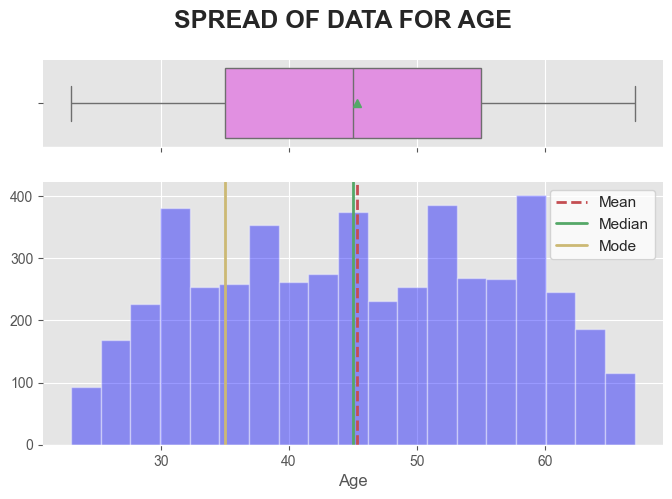

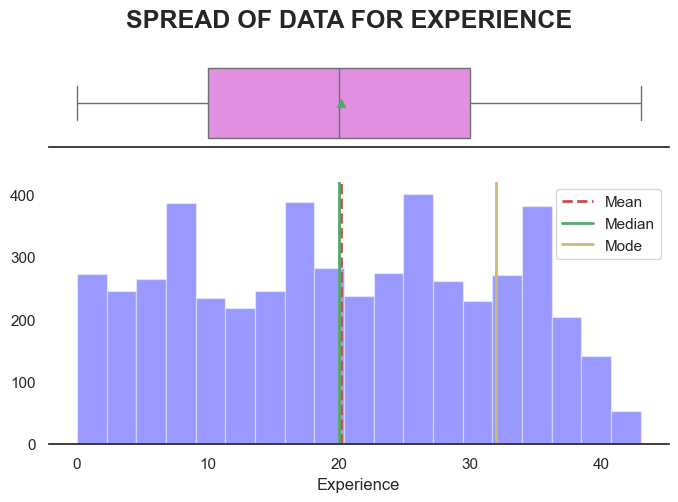

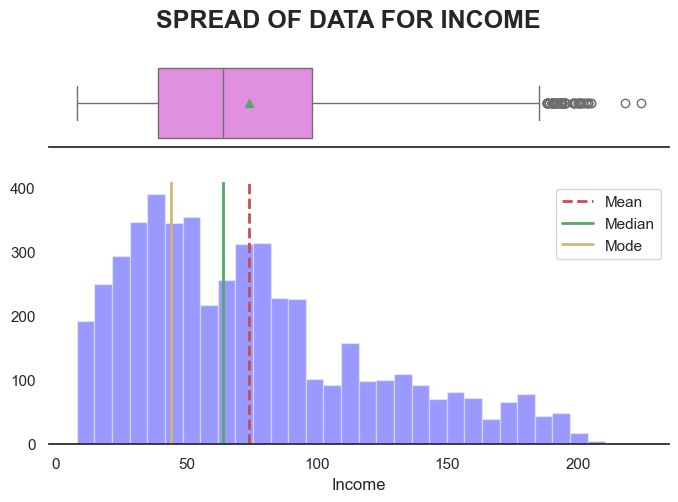

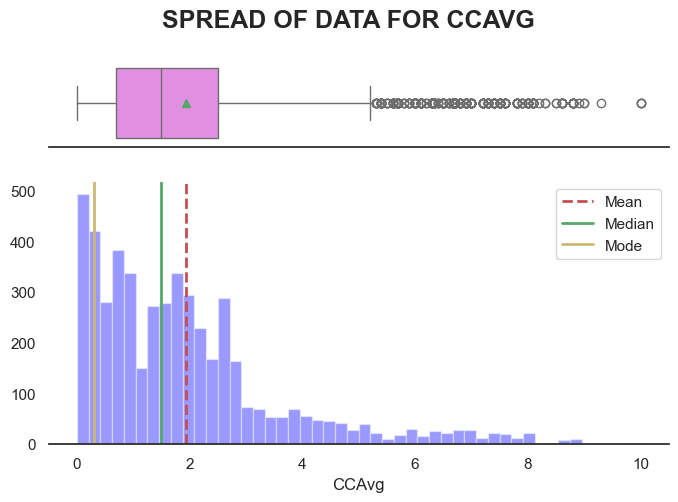

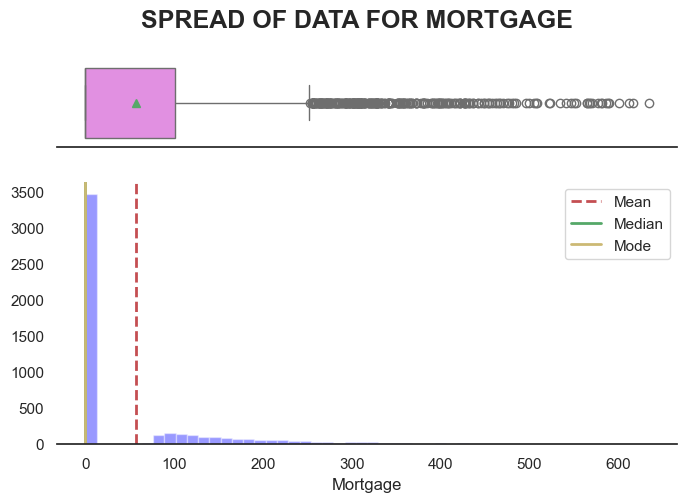

In [34]:

list_col=  ['Age','Experience','Income','CCAvg','Mortgage']
for i in range(len(list_col)):
    dist_box(df_loan[list_col[i]])

**Observations**
- Age and experience both has same distrubtion with spike at 5 points.
- Income is right skewed and has some outlier on higher side which can be clipped.
- Average montly credit is right skewed and has lot of outliers on higher side which can be clipped.
- Mortgage is  mostly 0 . but is  right skewed and has lot of outlier on higher side which can be clipped.



### Age
Age can be a vital factor in borrowinng loan, converting ages to bin to explore if there is any pattern, (So Age is now grouped)

In [35]:
df_loan['Agebin'] = pd.cut(df_loan['Age'], bins = [0, 30, 40, 50, 60, 100], labels = ['18-30', '31-40', '41-50', '51-60', '60-100'])
df_loan['Agebin']

0        18-30
1        41-50
2        31-40
3        31-40
4        31-40
         ...  
4995     18-30
4996     18-30
4997    60-100
4998    60-100
4999     18-30
Name: Agebin, Length: 5000, dtype: category
Categories (5, str): ['18-30' < '31-40' < '41-50' < '51-60' < '60-100']

### Income
To understand customers segments derving new columns which will help us identify if customer belongs to Upper , middle or lower income group 

In [36]:
df_loan["Income_group"] = pd.cut(
    x=df["Income"],
    bins=[0, 50, 140, 224],
    labels=["Lower", "Middle", "High"],
)

In [37]:
df_loan["Income_group"]

0        Lower
1        Lower
2        Lower
3       Middle
4        Lower
         ...  
4995     Lower
4996     Lower
4997     Lower
4998     Lower
4999    Middle
Name: Income_group, Length: 5000, dtype: category
Categories (3, str): ['Lower' < 'Middle' < 'High']

### Spending
To understand customers spending derving new columns which will say if customer belongs to Upper , middle or lower spending

In [38]:
df_loan.CCAvg.describe()

count   5000.00000
mean       1.93794
std        1.74766
min        0.00000
25%        0.70000
50%        1.50000
75%        2.50000
max       10.00000
Name: CCAvg, dtype: float64

In [39]:
df_loan["Spending_group"] = pd.cut( x=df_loan["CCAvg"], bins=[0.00000, 0.70000, 2.50000, 10.00000],
    labels=["Low", "Medium", "High"],include_lowest=True ,
)

In [ ]:

cat_columns = ['Family','Education','PersonalLoan','SecuritiesAccount',
               'CDAccount','Online','CreditCard','Agebin','Income_group','Spending_group']
title=['Number of Family','Education','Customers who took Personal Loan',
       ' Customer has Securities Account','Customers has a CD Account',
       'Customers  who transcat  Online',' Customers who has  Credit Card','Agebins',"Income group",'Spending group']
plt.figure(figsize=(14,20))

sns.set_theme(style="white") 

for i, variable in enumerate(cat_columns):
                     plt.subplot(5,2,i+1)
                     order = df_loan[variable].value_counts(ascending=False).index   
                     
                     sns.set_palette('Set2')
                     ax=sns.countplot(x=df_loan[variable], data=df_loan )
                     sns.despine(top=True,right=True,left=True)
                     for p in ax.patches:
                           percentage = '{:.1f}%'.format(100 * p.get_height()/len(df_loan[variable]))
                           x = p.get_x() + p.get_width() / 2 - 0.05
                           y = p.get_y() + p.get_height()
                           plt.annotate(percentage, (x, y),ha='center')
                     plt.tight_layout()
                     plt.title(title[i].upper())
                                     


**Observations**
- `~29.4 %` customers are single.
- `~41.9%` customers are undergrad.
- `~9.6%` bought  a personal loan from the bank.
- `10.4 %` customers have a securities account with the bank
- `6 %` customer have a CD account.
- `60%` customers  transact online.
- `29.4%` customers have  credit cards.  
- `~ 76 %` of customers  are in range of 31- 60.
- `~ 50 %` Most of bank customers belong to middle income group.
- `~48 %` of customers has medium Average spending

In [ ]:
df_loan.groupby(['County', 'PersonalLoan']).size().unstack(fill_value=0)

PersonalLoan,0,1
County,,
9307,1,0
96651,6,0
Alameda County,456,44
Butte County,17,2
Contra Costa County,73,12
El Dorado County,16,1
Fresno County,24,2
Humboldt County,30,2
Imperial County,3,0


### For each county, how many customers accepted or did not accept a personal loan
#### 0 meant Customer did NOT accept/take the loan

<Axes: ylabel='County'>

<Figure size 1500x2400 with 0 Axes>

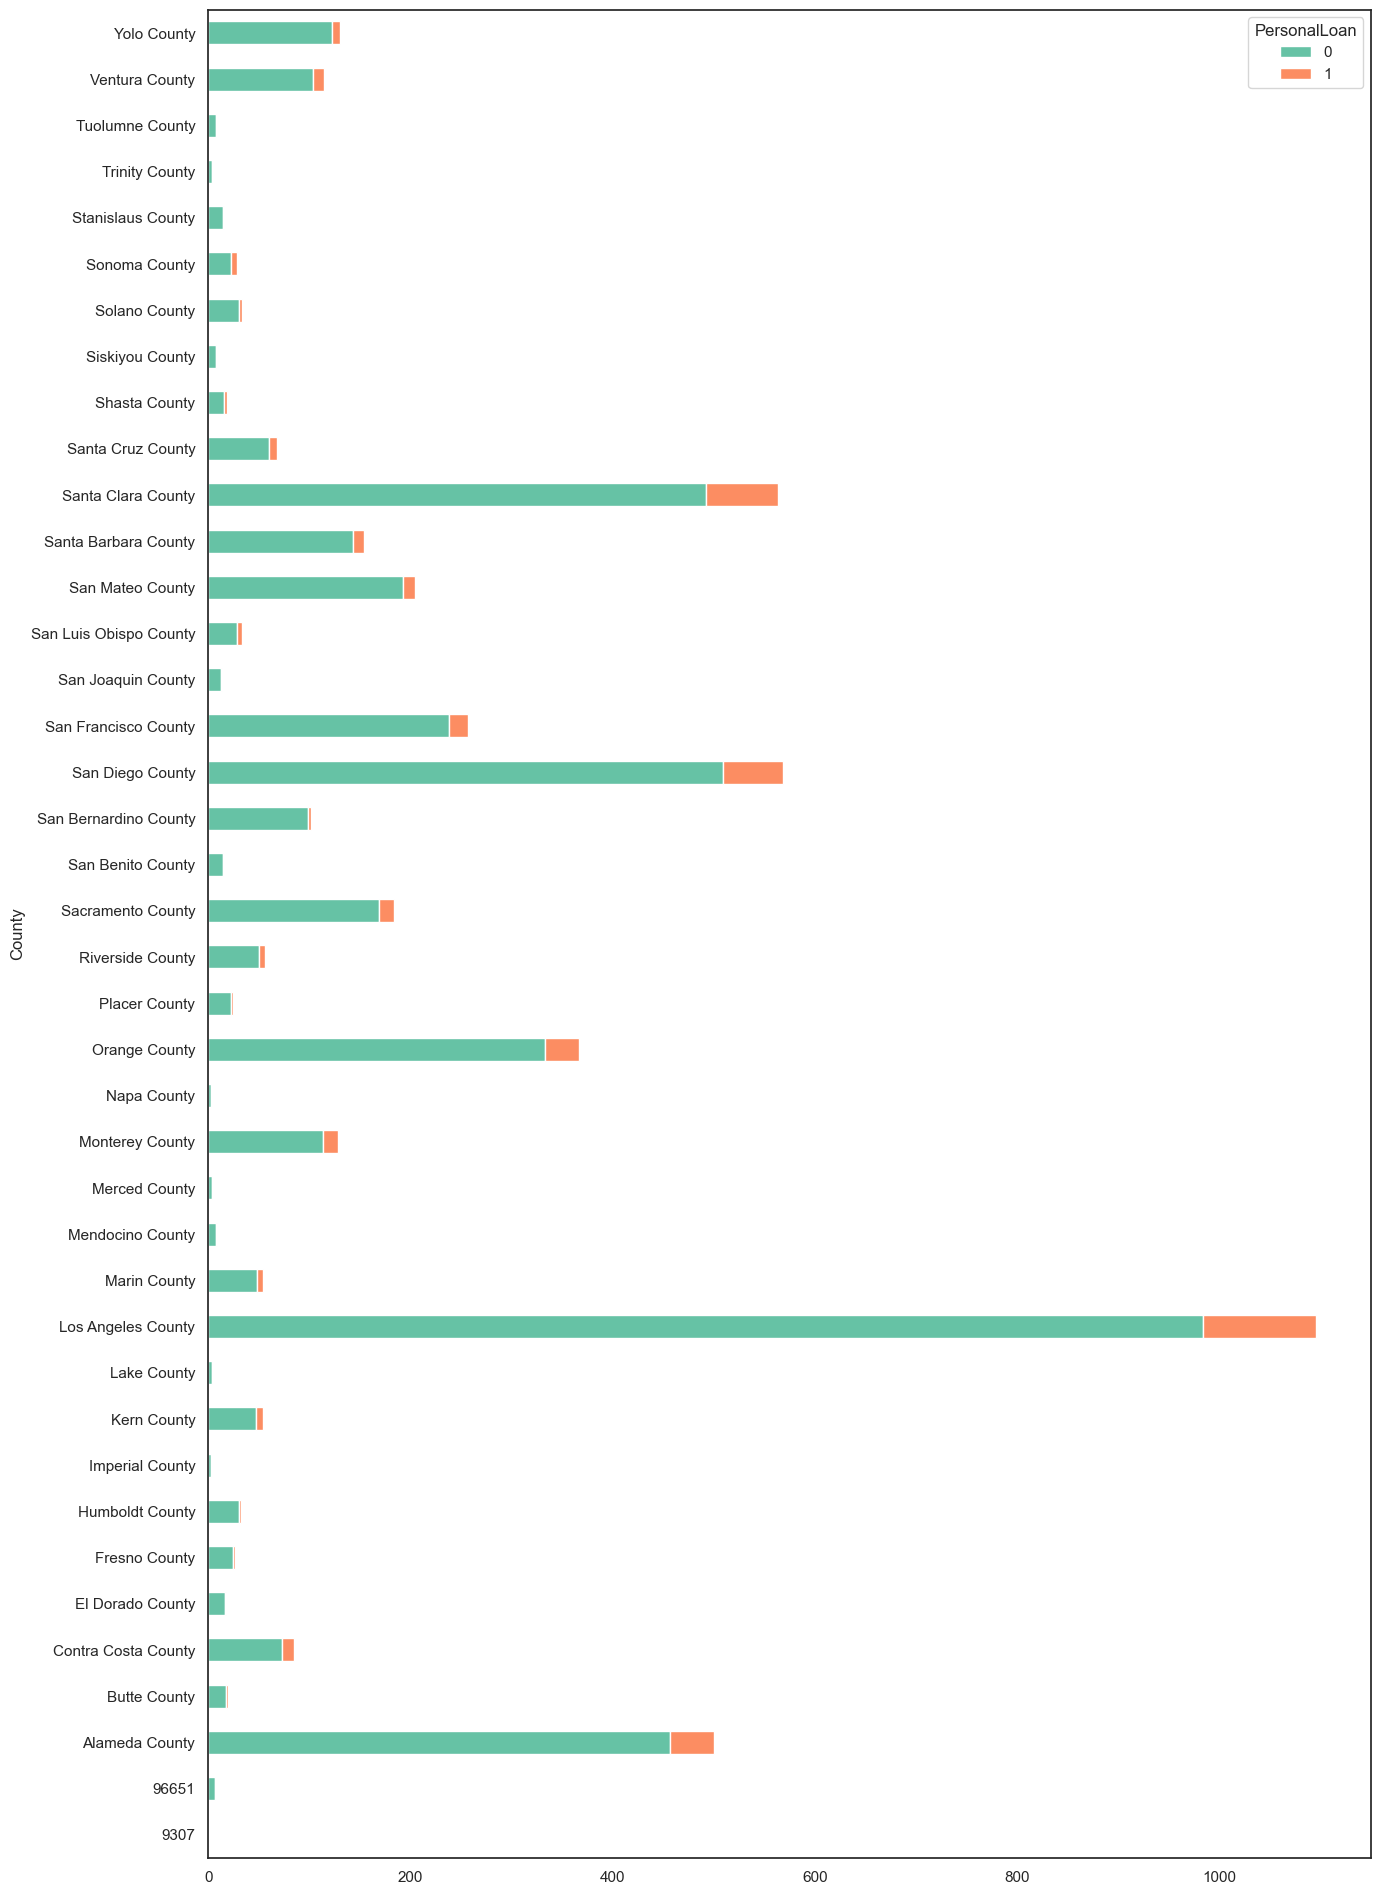

In [ ]:
plt.figure(figsize=(15,24))

pd.crosstab(index=df_loan['County'],columns=df_loan['PersonalLoan'].sort_values(ascending=False)).plot(kind='barh',stacked=True,figsize=(15,24))

**It can be seen the percentage of loan taken from various country differ.There are so many county converting them to regions will help in our model**


In [ ]:
counties = {
'Los Angeles County':'Los Angeles Region',
'San Diego County':'Southern',
'Santa Clara County':'Bay Area',
'Alameda County':'Bay Area',
'Orange County':'Southern',
'San Francisco County':'Bay Area',
'San Mateo County':'Bay Area',
'Sacramento County':'Central',
'Santa Barbara County':'Southern',
'Yolo County':'Central',
'Monterey County':'Bay Area',            
'Ventura County':'Southern',             
'San Bernardino County':'Southern',       
'Contra Costa County':'Bay Area',        
'Santa Cruz County':'Bay Area',           
'Riverside County':'Southern',            
'Kern County':'Southern',                 
'Marin County':'Bay Area',                
'San Luis Obispo County':'Southern',     
'Solano County':'Bay Area',              
'Humboldt County':'Superior',            
'Sonoma County':'Bay Area',                
'Fresno County':'Central',               
'Placer County':'Central',                
'Butte County':'Superior',               
'Shasta County':'Superior',                
'El Dorado County':'Central',             
'Stanislaus County':'Central',            
'San Benito County':'Bay Area',          
'San Joaquin County':'Central',           
'Mendocino County':'Superior',             
'Tuolumne County':'Central',                
'Siskiyou County':'Superior',              
'Trinity County':'Superior',                
'Merced County':'Central',                  
'Lake County':'Superior',                 
'Napa County':'Bay Area',                   
'Imperial County':'Southern',
93077:'Southern',
96651:'Bay Area'
}

**Converting the county to regions based on  https://www.calbhbc.org/region-map-and-listing.html**

In [ ]:

df_loan['Regions'] = df_loan['County'].map(counties)

In [ ]:
df_loan['Regions'].unique()

<ArrowStringArray>
['Los Angeles Region', 'Bay Area', 'Southern', 'Superior', 'Central', nan]
Length: 6, dtype: str

In [ ]:
df_loan.isnull().sum()

Age                  0
Experience           0
Income               0
ZIPCode              0
Family               0
CCAvg                0
Education            0
Mortgage             0
PersonalLoan         0
SecuritiesAccount    0
CDAccount            0
Online               0
CreditCard           0
County               0
Agebin               0
Income_group         0
Spending_group       0
Regions              1
dtype: int64

In [ ]:
df_loan.dropna(inplace=True)

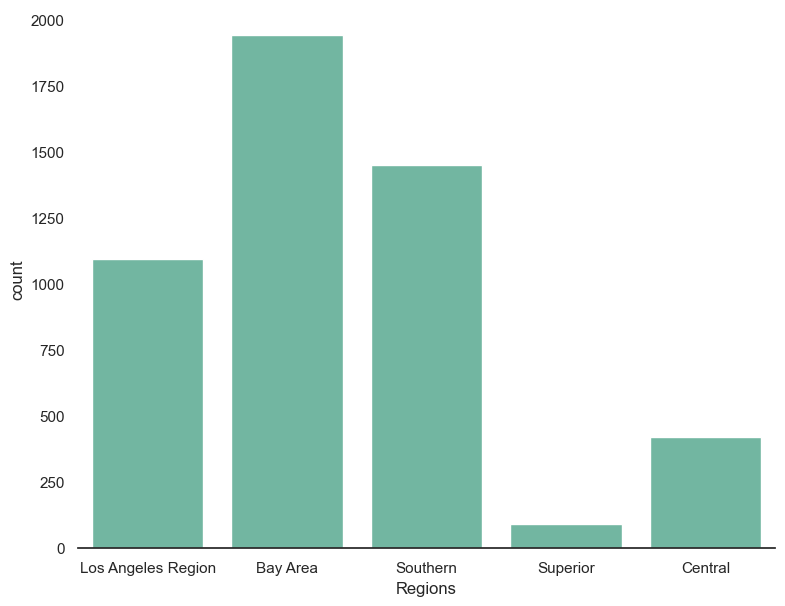

In [ ]:
plt.figure(figsize=(9,7))
sns.countplot(data=df_loan,x=df_loan['Regions'])
sns.despine(top=True,right=True,left=True) 

In [ ]:
df_loan.info()

<class 'pandas.DataFrame'>
Index: 4999 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                4999 non-null   int64   
 1   Experience         4999 non-null   int64   
 2   Income             4999 non-null   int64   
 3   ZIPCode            4999 non-null   category
 4   Family             4999 non-null   category
 5   CCAvg              4999 non-null   float64 
 6   Education          4999 non-null   category
 7   Mortgage           4999 non-null   int64   
 8   PersonalLoan       4999 non-null   category
 9   SecuritiesAccount  4999 non-null   category
 10  CDAccount          4999 non-null   category
 11  Online             4999 non-null   category
 12  CreditCard         4999 non-null   category
 13  County             4999 non-null   category
 14  Agebin             4999 non-null   category
 15  Income_group       4999 non-null   category
 16  Spending_group     499

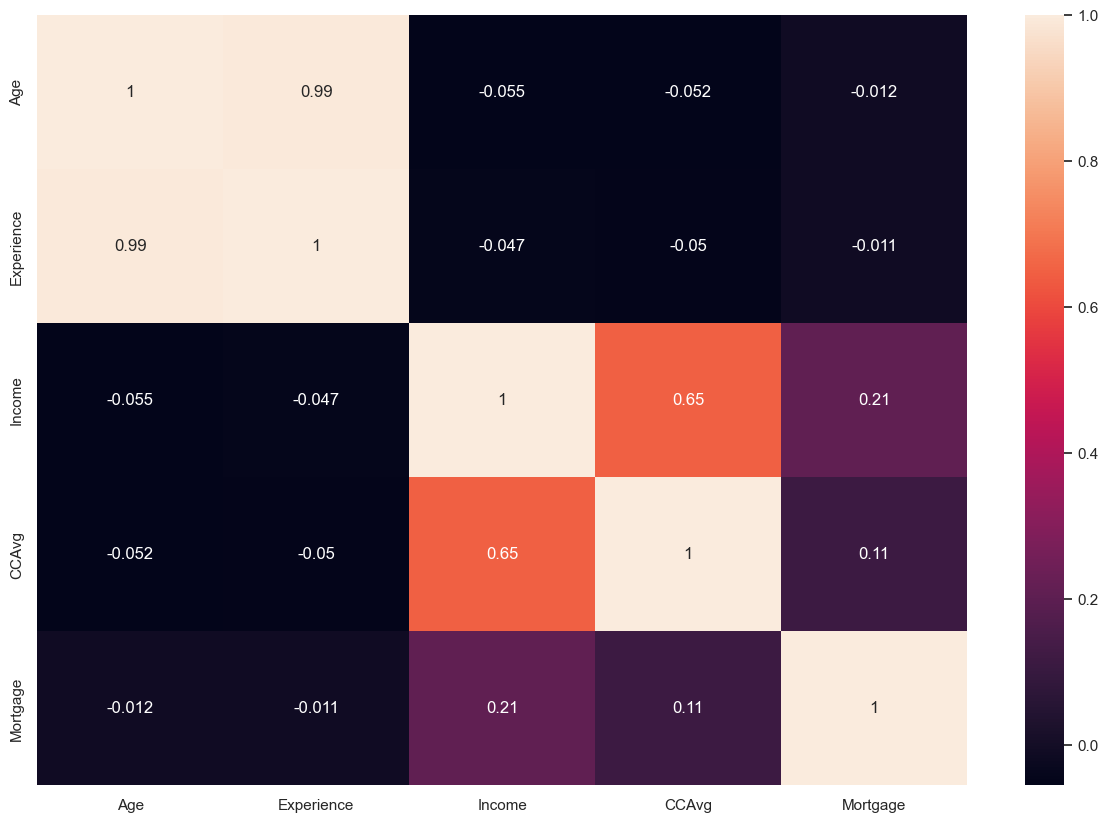

In [ ]:
sns.set_palette(sns.color_palette("Set2", 8))
plt.figure(figsize=(15,10))
sns.heatmap(df_loan.corr(numeric_only=True), annot=True)
plt.show()

**Observations**
- As expected Age and experience are highly correlated and one of them can be dropped.Since we had to handle 0, will drop experience.
- Income and Average spending on  credit card are  positively corrleated.
- Mortgage has very little correlation with income.


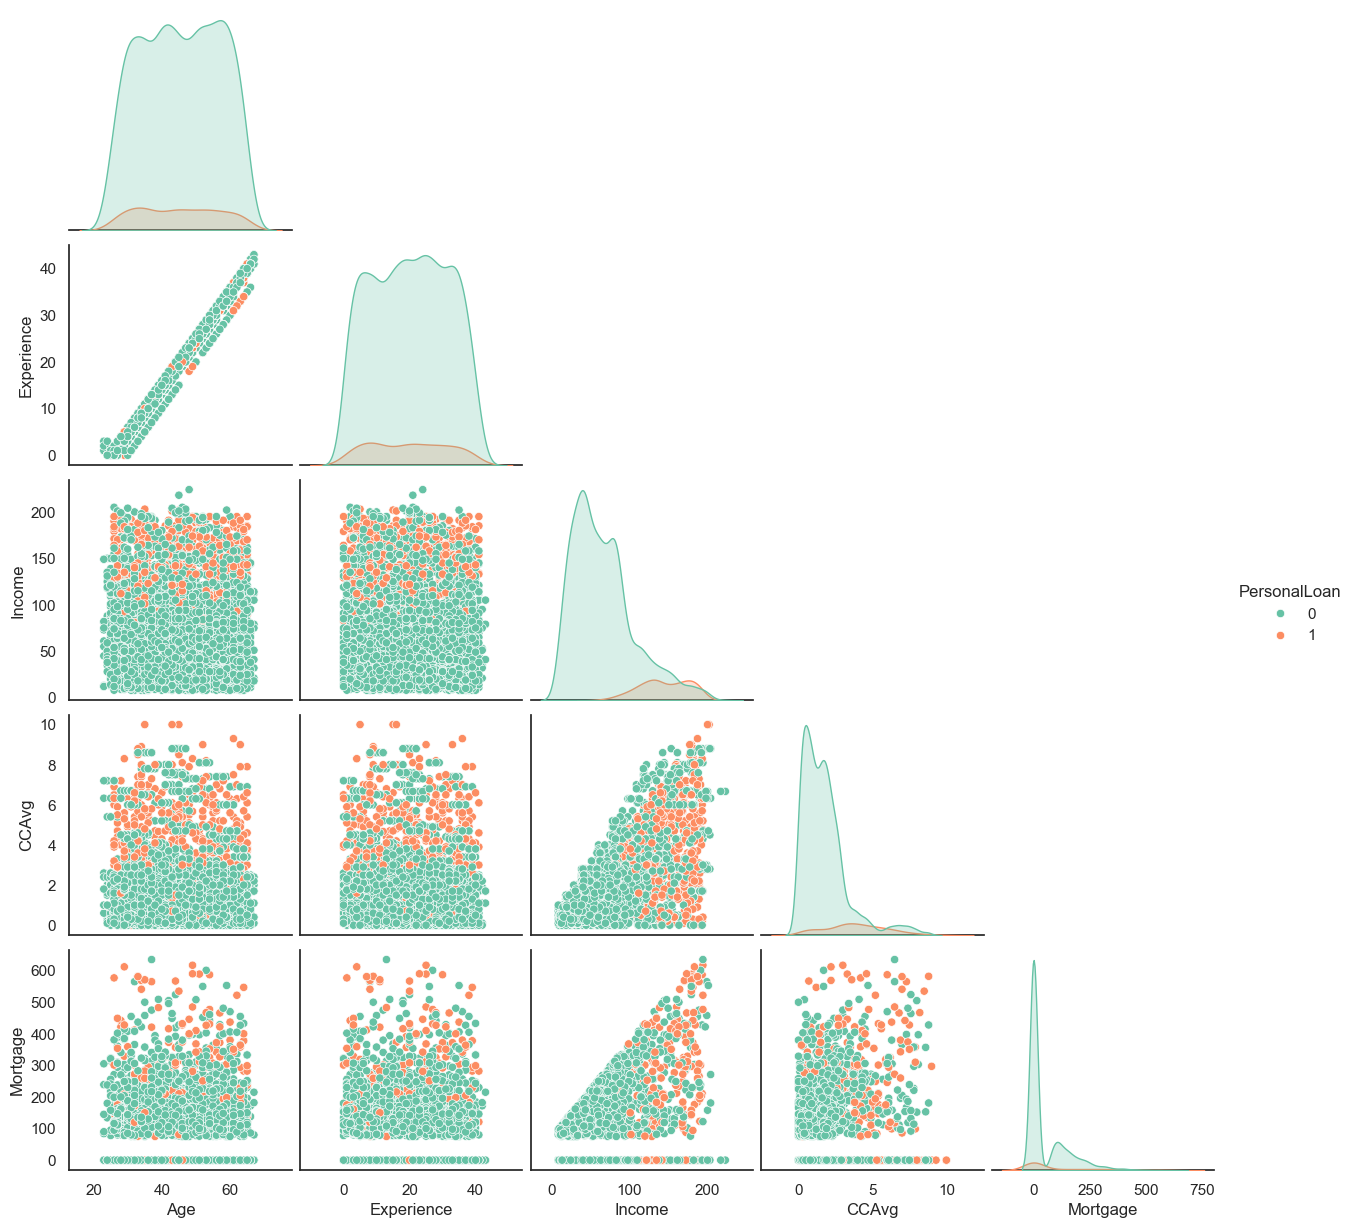

In [ ]:
sns.set_palette(sns.color_palette("Set2", 8))
sns.pairplot(df_loan, hue="PersonalLoan",corner=True)
plt.show()

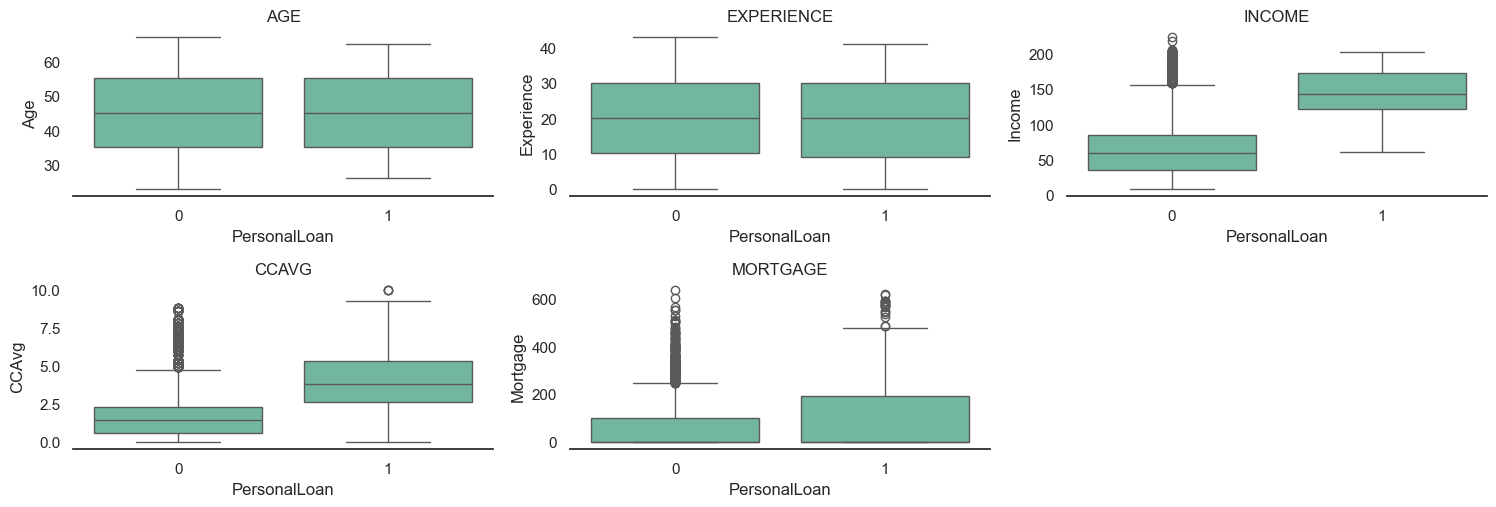

In [ ]:
numeric_columns = ['Age','Experience','Income','CCAvg','Mortgage']
plt.figure(figsize=(15,25))

sns.set_palette(sns.color_palette("Set2", 8))
for i, variable in enumerate(numeric_columns):
        plt.subplot(10,3,i+1)
        
        sns.boxplot(x='PersonalLoan',y= df_loan[variable], data=df_loan)     
        sns.despine(top=True,right=True,left=True) # to remove side line from graph
        plt.tight_layout()
        plt.title(variable.upper())

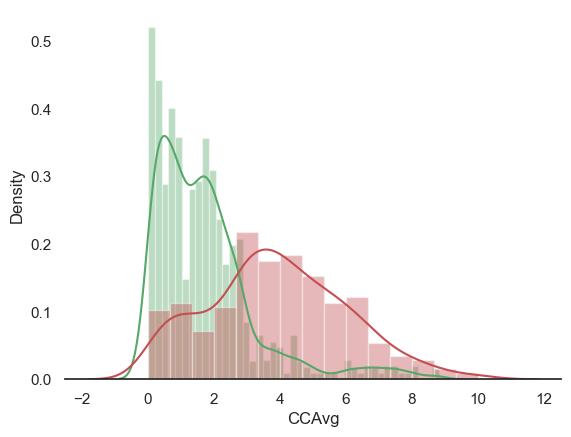

In [ ]:
sns.distplot( df_loan[df_loan['PersonalLoan'] == 0]['CCAvg'], color = 'g')
sns.distplot( df_loan[df_loan['PersonalLoan'] == 1]['CCAvg'], color = 'r')
sns.despine(top=True,right=True,left=True)

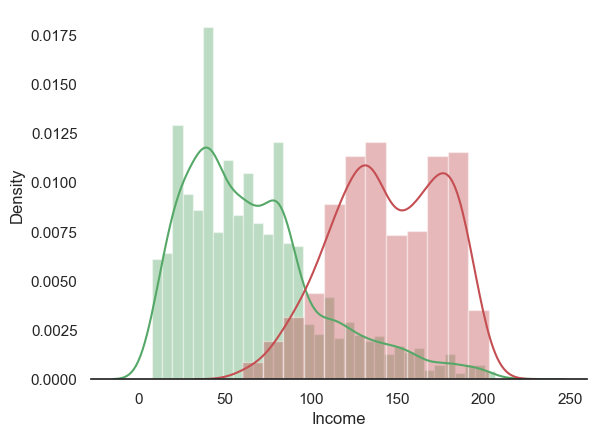

In [ ]:
sns.distplot( df_loan[df_loan['PersonalLoan'] == 0]['Income'], color = 'g')
sns.distplot( df_loan[df_loan['PersonalLoan'] == 1]['Income'], color = 'r')
sns.despine(top=True,right=True,left=True) 

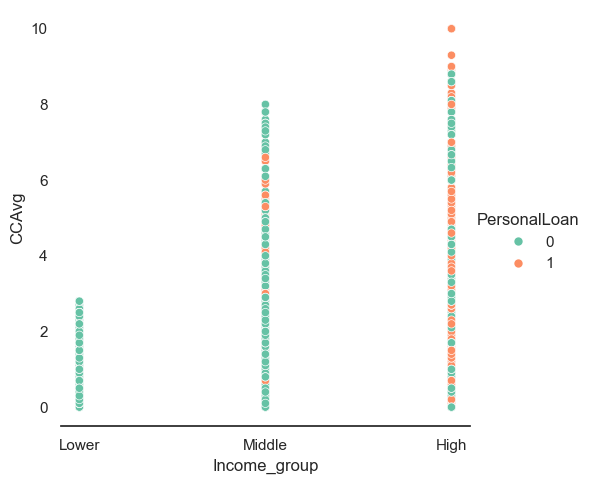

In [ ]:
sns.relplot(x='Income_group',y='CCAvg',hue='PersonalLoan',data=df_loan)
sns.despine(top=True,right=True,left=True)

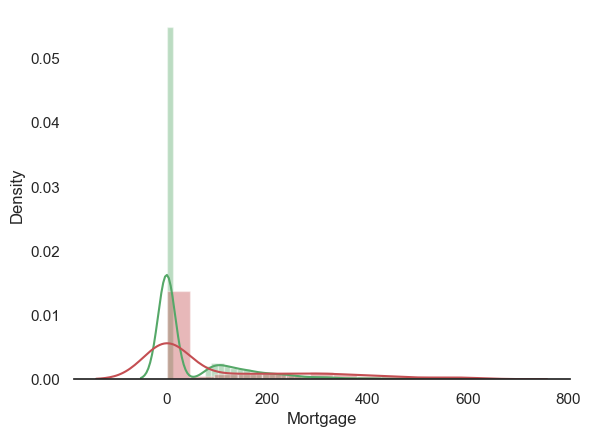

In [ ]:
sns.distplot( df_loan[df_loan['PersonalLoan'] == 0]['Mortgage'], color = 'g')
sns.distplot( df_loan[df_loan['PersonalLoan'] == 1]['Mortgage'], color = 'r')
sns.despine(top=True,right=True,left=True)

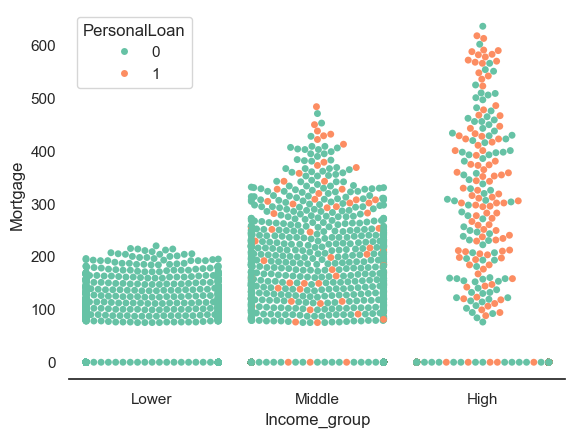

In [ ]:
sns.swarmplot(x='Income_group',y='Mortgage',hue='PersonalLoan',data=df_loan)
sns.despine(top=True,right=True,left=True) 

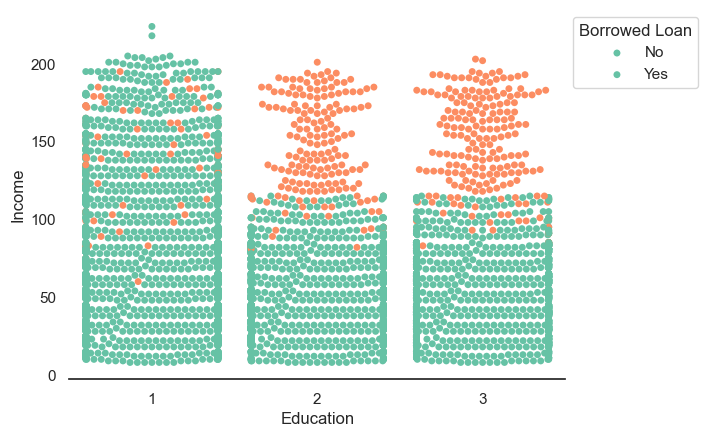

In [ ]:
sns.swarmplot(x='Education',y='Income',hue='PersonalLoan',data=df_loan)
sns.despine(top=True,right=True,left=True) 
labels=["No","Yes"]
plt.legend(loc='lower left', frameon=False,)
plt.legend(loc="upper left", labels=labels,title="Borrowed Loan",bbox_to_anchor=(1,1))

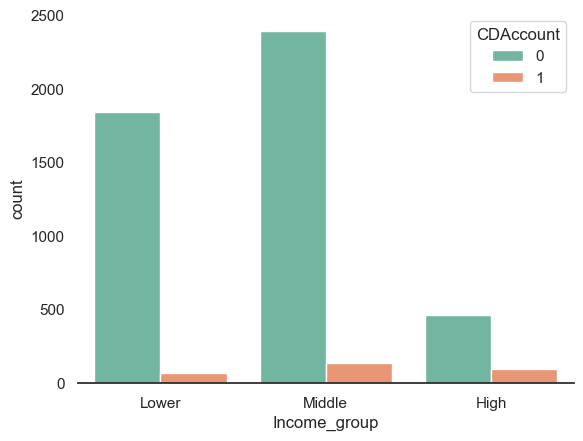

In [ ]:
sns.countplot(x='Income_group',hue='CDAccount',data=df_loan)
sns.despine(top=True,right=True,left=True) 

In [ ]:
df_loan['CDAccount'].value_counts()

CDAccount
0    4697
1     302
Name: count, dtype: int64

In [ ]:
df_loan[df_loan['CDAccount'] == 1].shape[0]

302

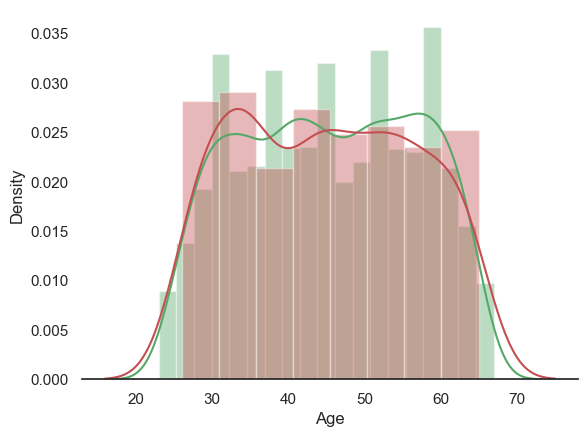

In [ ]:
sns.distplot( df_loan[df_loan['PersonalLoan'] == 0]['Age'], color = 'g')
sns.distplot( df_loan[df_loan['PersonalLoan'] == 1]['Age'], color = 'r')
sns.despine(top=True,right=True,left=True)

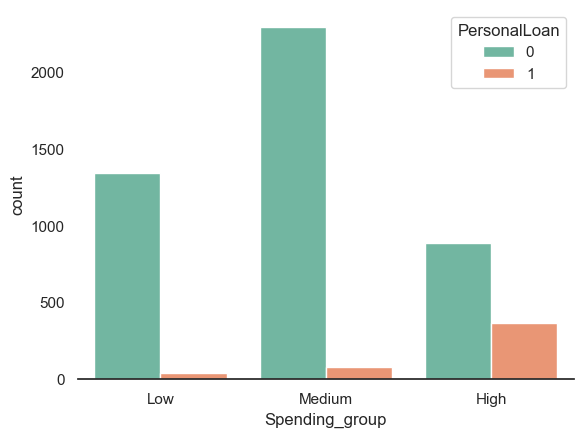

In [ ]:
sns.countplot(x='Spending_group',hue='PersonalLoan',data=df_loan)
sns.despine(top=True,right=True,left=True)

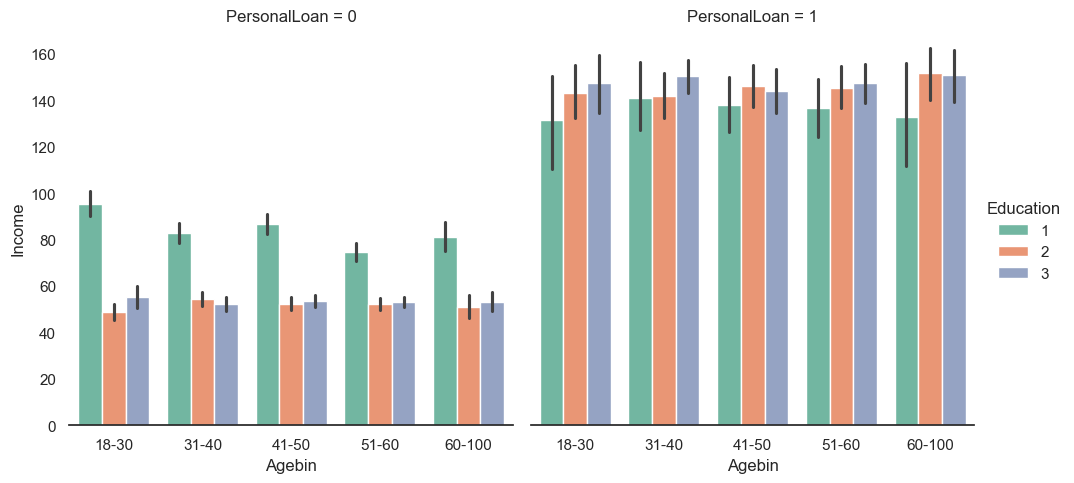

In [ ]:
sns.catplot(y='Income',x='Agebin',hue='Education',kind='bar',col="PersonalLoan", data=df_loan)
sns.despine(top=True,right=True,left=True)

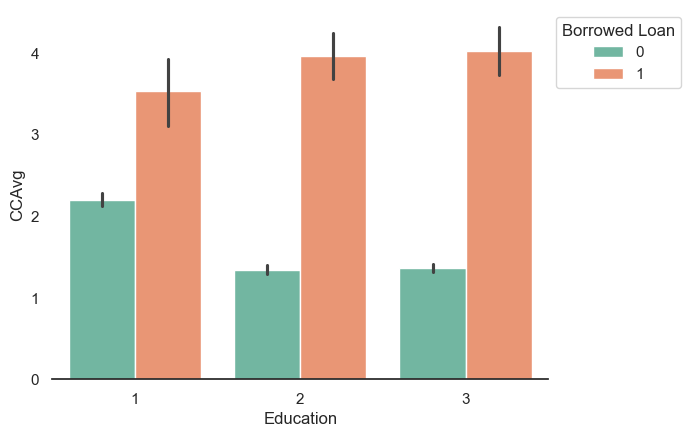

In [ ]:
sns.set_palette(sns.color_palette("Set2", 8))
sns.barplot(y='CCAvg',x='Education', hue='PersonalLoan',data=df_loan)
labels=["No","Yes"]
plt.legend(loc="upper left", title="Borrowed Loan",bbox_to_anchor=(1,1))
sns.despine(top=True,right=True,left=True)

**Observations**
   
- People with higher income had opted for personal loan before.
    
- People with high mortgages opted for loan.
    
- Customers with higher average monthly credit usage have opted for loan.    
   
- Customers with higher income had higher average credit card usage and mortgage.

- Graduate and Advanced/Professional have higher monhtly  credit card usage and have borrowed loans with the bank.

In [ ]:
def stacked_plot(x):
    sns.set_palette(sns.color_palette("Set2", 8))
    tab1 = pd.crosstab(x,df_loan['PersonalLoan'],margins=True)
    print(tab1)
    print('-'*120)
    tab = pd.crosstab(x,df_loan['PersonalLoan'],normalize='index')
    tab.plot(kind='bar',stacked=True,figsize=(7,4))
    plt.xticks(rotation=360)
    labels=["No","Yes"]
    plt.legend(loc='lower left', frameon=False,)
    plt.legend(loc="upper left", labels=labels,title="Borrowed Loan",bbox_to_anchor=(1,1))
    sns.despine(top=True,right=True,left=True) 
    plt.show()

PersonalLoan     0    1   All
Family                       
1             1365  107  1472
2             1190  106  1296
3              877  133  1010
4             1087  134  1221
All           4519  480  4999
------------------------------------------------------------------------------------------------------------------------


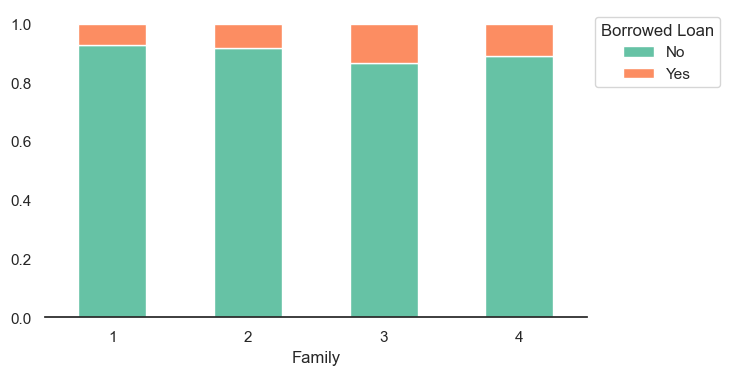

PersonalLoan     0    1   All
Education                    
1             2003   93  2096
2             1221  182  1403
3             1295  205  1500
All           4519  480  4999
------------------------------------------------------------------------------------------------------------------------


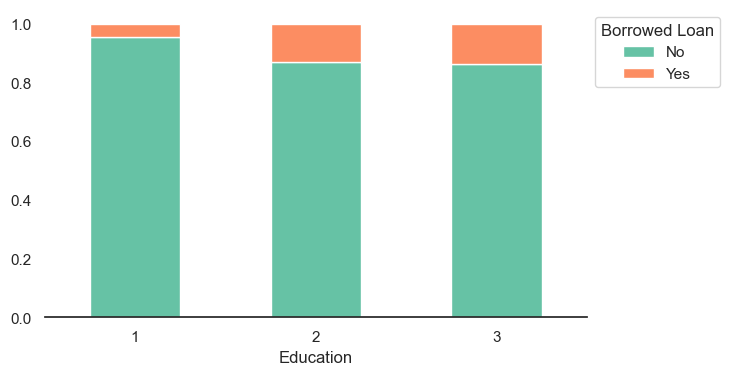

PersonalLoan          0    1   All
SecuritiesAccount                 
0                  4057  420  4477
1                   462   60   522
All                4519  480  4999
------------------------------------------------------------------------------------------------------------------------


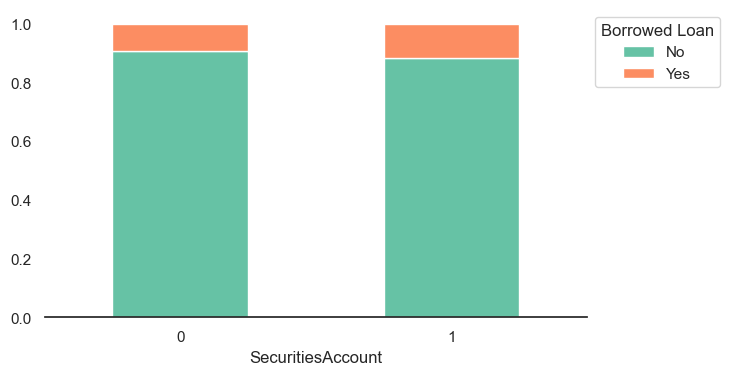

PersonalLoan     0    1   All
CDAccount                    
0             4357  340  4697
1              162  140   302
All           4519  480  4999
------------------------------------------------------------------------------------------------------------------------


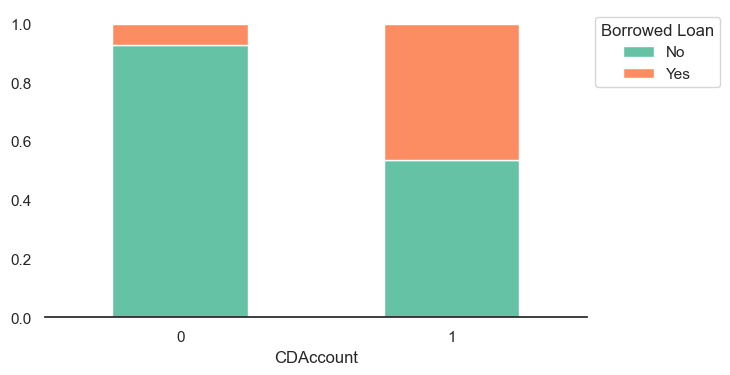

PersonalLoan     0    1   All
CreditCard                   
0             3193  337  3530
1             1326  143  1469
All           4519  480  4999
------------------------------------------------------------------------------------------------------------------------


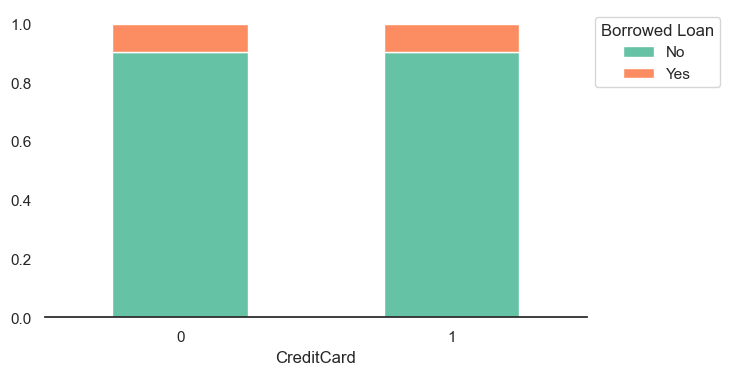

PersonalLoan     0    1   All
Online                       
0             1827  189  2016
1             2692  291  2983
All           4519  480  4999
------------------------------------------------------------------------------------------------------------------------


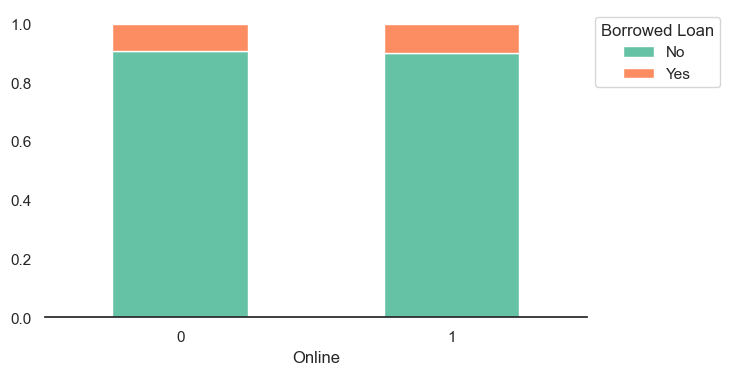

PersonalLoan           0    1   All
Regions                            
Bay Area            1747  196  1943
Central              390   30   420
Los Angeles Region   984  111  1095
Southern            1314  135  1449
Superior              84    8    92
All                 4519  480  4999
------------------------------------------------------------------------------------------------------------------------


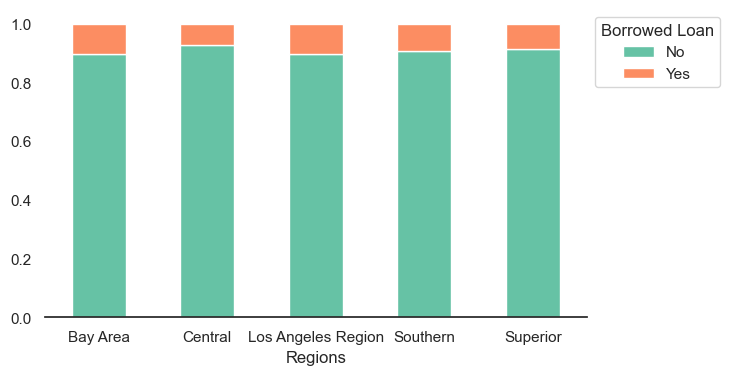

PersonalLoan     0    1   All
Agebin                       
18-30          558   66   624
31-40         1118  118  1236
41-50         1148  122  1270
51-60         1207  115  1322
60-100         488   59   547
All           4519  480  4999
------------------------------------------------------------------------------------------------------------------------


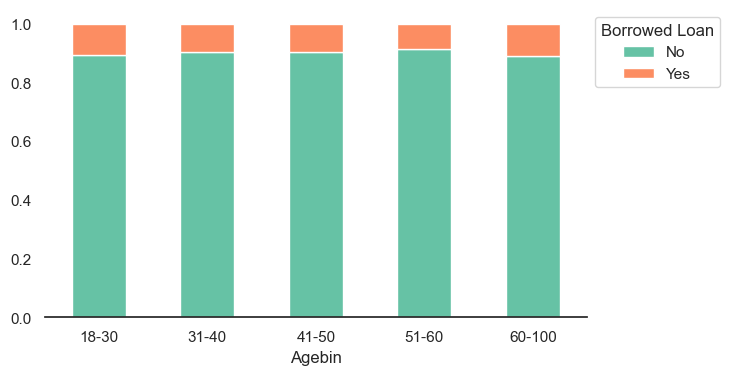

PersonalLoan     0    1   All
Income_group                 
Lower         1913    0  1913
Middle        2301  223  2524
High           305  257   562
All           4519  480  4999
------------------------------------------------------------------------------------------------------------------------


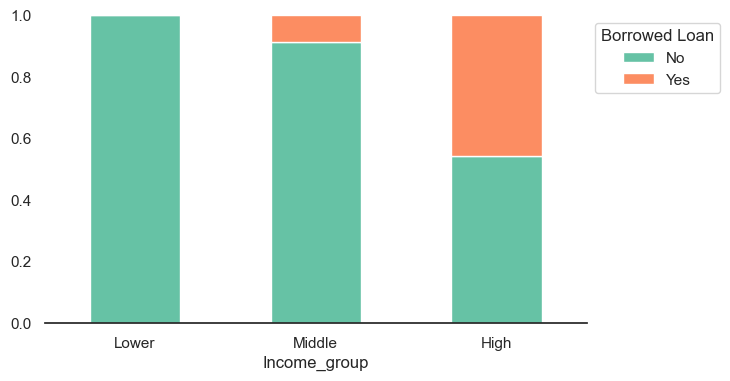

PersonalLoan       0    1   All
Spending_group                 
Low             1341   39  1380
Medium          2292   79  2371
High             886  362  1248
All             4519  480  4999
------------------------------------------------------------------------------------------------------------------------


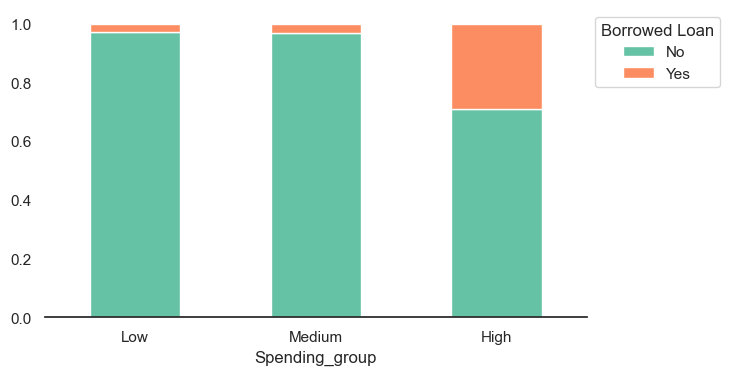

In [ ]:
cat_columns=['Family','Education','SecuritiesAccount','CDAccount','CreditCard','Online','Regions','Agebin','Income_group','Spending_group']
for i, variable in enumerate(cat_columns):
       stacked_plot(df_loan[variable])

In [ ]:
df_loan.groupby('PersonalLoan')['CCAvg'].mean()

PersonalLoan
0   1.72926
1   3.90535
Name: CCAvg, dtype: float64

**Observations**
- Number of Customers  with Family size of  3 who had  borrowed loans from the bank is greatet than other family size
- 60 of those who had Personal loan with the bank also had Securities_Account.
- Customers who had certificate of deposit  with the bank had previously borrowed loan
- Customers using Online facilities has no impact on personal loan
- Majority customers who did have Personal loan with the bank did not used CrediCard from other banks.
- Majority customers who had take personal loan before are from LosAngeles and Bay region.
- Ratio of borrowing loan is high in 30 and below and 60 and above customers.
- Customer with high average Monthly spending have bought personal loan before
- As expected Age and experience are highly correlated and one of them can be dropped. Since experience had negative values dropping experience would be better option.


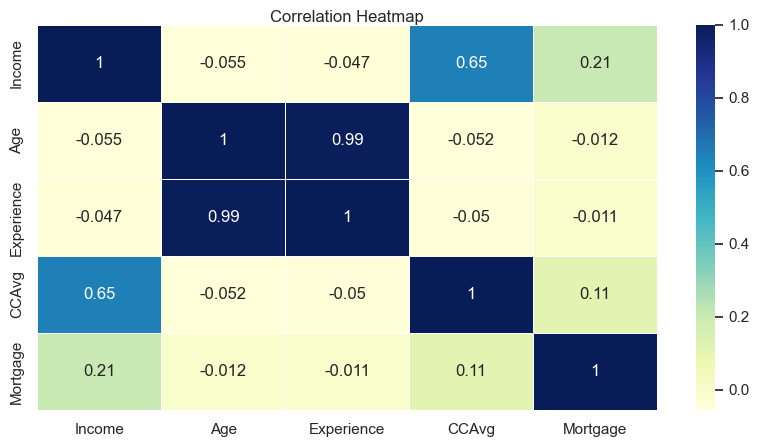

In [ ]:
plt.figure(figsize=(10,5))
numerical=['Income','Age','Experience','CCAvg','Mortgage']
heatmap = sns.heatmap(df_loan[numerical].corr(), annot=True, cmap='YlGnBu',linewidths=0.5)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=2);

### Check  distrubution in target column

([<matplotlib.patches.Wedge at 0x1a9bc72fb60>,
 [Text(-1.050331338801288, 0.3268089330662395, ''),
  Text(1.0503312894545003, -0.32680909166185557, '')],
 [Text(-0.5729080029825208, 0.17825941803613063, '90.4%'),
  Text(0.572907976066091, -0.1782595045428303, '9.6%')])

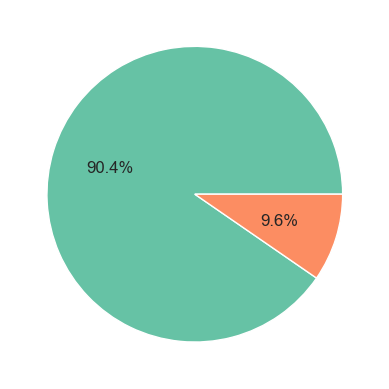

In [ ]:

plt.pie(data=df_loan,x=df_loan["PersonalLoan"].value_counts(),autopct='%1.1f%%')

##### The target variable personal_loan is highly imbalanced where only 9.6% of the customers have previously opted for a personal loan in the dataset. This can be handled using weight or SMOTE.But for now we will carry with on without SMOTE 

In [ ]:
df_loan.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Agebin,Income_group,Spending_group,Regions
0,25,1,49,91107,4,1.60000,1,0,0,1,0,0,0,Los Angeles County,18-30,Lower,Medium,Los Angeles Region
1,45,19,34,90089,3,1.50000,1,0,0,1,0,0,0,Los Angeles County,41-50,Lower,Medium,Los Angeles Region
2,39,15,11,94720,1,1.00000,1,0,0,0,0,0,0,Alameda County,31-40,Lower,Medium,Bay Area
3,35,9,100,94112,1,2.70000,2,0,0,0,0,0,0,San Francisco County,31-40,Middle,High,Bay Area
4,35,8,45,91330,4,1.00000,2,0,0,0,0,0,1,Los Angeles County,31-40,Lower,Medium,Los Angeles Region


In [ ]:
# Saving dataset before treating outliers for logistic regression.
df_Decision = df_loan.copy()

## Insights based on EDA

### <a id='link1'>Summary of EDA</a>
**Data Description:**

* Dependent variable is the Personal_loan which is of categorical data type.
* Age, Experience, Income,mortage ,CCavg are of integer type while other variables are of categorical type
* There were no missing values in the dataset.

**Data Cleaning:**

* We observed that some observations where experience = -ve but since there was a strong correlation with age , we dropped experience.
* There are 450 unique zipcode, we mapped it to counties. They were further mapped to regions to reduce the dimension of data and we now have only 5 distinct values in the data.
* We also created Age bin ,Spending group and Incomegroup to analyse in there is any pattern in buying loan based on these.

**Observations from EDA:**
- People with higher income had opted for personal loan before.
- People with high mortgages opted for loan.
- Customers will higher average monthly credit usage have opted for loan.  
- Customers with Family of 3 members had  borrowed the loans with the bank.
- Education level 2: Graduate and 3: Advanced/Professional  have borrowed loans with the bank.
- Customers who had certificate of deposit  with the bank had previously borrowed loan
- Majority of customers who did have Personal loan with the bank used Online facilities.
- Majority customers who had take personal loan before are from LosAngeles region.
- Ratio of borrowing loan is high in 30 and below and 60 and above customers.
- The more income you get the more you spend and have a "large than life" lifestyle.

##### Customer segmentation for borrowing  loan based on EDA
 - Customer with Higher income have higher mortages and higher monthly average spending.They also have certificate of deposit with the bank.They are our high profile clients.
 - Few Customer in medium income  group don't have higher mortages and have less average monthly credit card spending .They are average profile clients.
 - Customer in lower income group  have less mortages( few outliers are there) ,less monthly spending. They are our low profile clients.
  
   
**Actions for data pre-processing:**

* Many variables have outliers that need to be treated.
* We can drop Experience, Country,Zipcode and Agebin,Income_group,Spending_group.

### Outliers detection

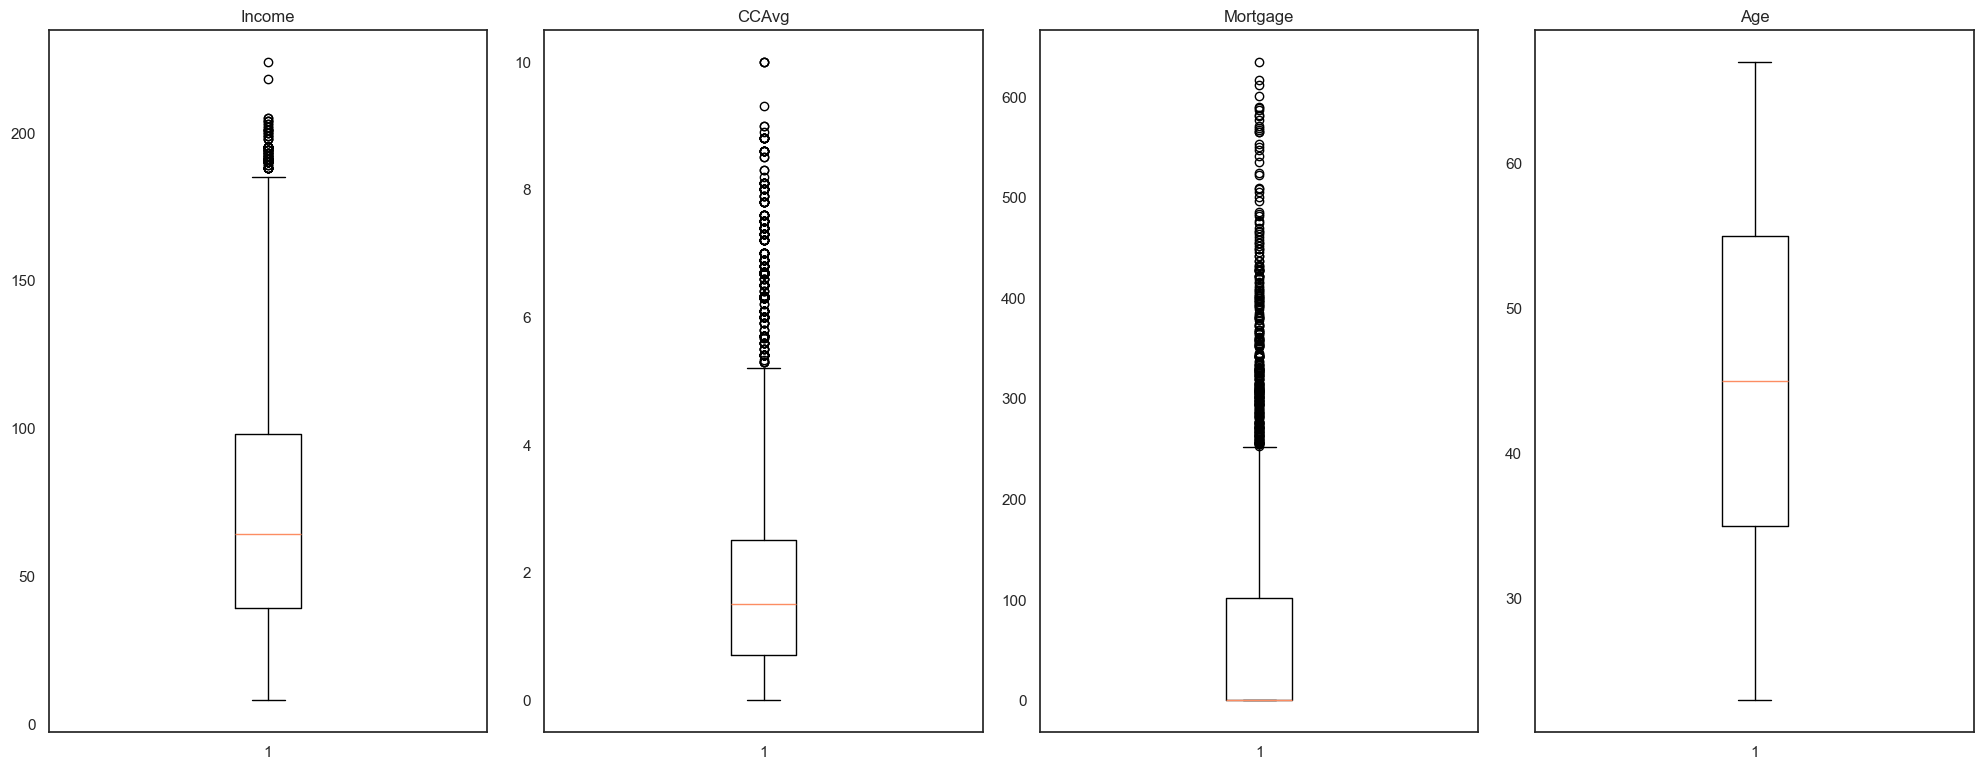

In [ ]:
numeric_columns =['Income','CCAvg','Mortgage','Age']
# outlier detection using boxplot
plt.figure(figsize=(20,30))

for i, variable in enumerate(numeric_columns):
                     plt.subplot(4,4,i+1)
                     plt.boxplot(df_loan[variable],whis=1.5)
                     plt.tight_layout()
                     plt.title(variable)

plt.show()

In [ ]:

df_loan.sort_values(by=["Income"],ascending = False).head(5)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Agebin,Income_group,Spending_group,Regions
3896,48,24,224,93940,2,6.67000,1,0,0,0,1,1,1,Monterey County,41-50,High,High,Bay Area
4993,45,21,218,91801,2,6.67000,1,0,0,0,0,1,0,Los Angeles County,41-50,High,High,Los Angeles Region
526,26,2,205,93106,1,6.33000,1,271,0,0,0,0,1,Santa Barbara County,18-30,High,High,Southern
2988,46,21,205,95762,2,8.80000,1,181,0,1,0,1,0,El Dorado County,41-50,High,High,Central
2278,30,4,204,91107,2,4.50000,1,0,0,0,0,1,0,Los Angeles County,18-30,High,High,Los Angeles Region


In [ ]:
df_loan.loc[(df_loan['Age']==48) & (df_loan['Experience']==24)].sort_values(by=['Income'],ascending=False).head(5)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Agebin,Income_group,Spending_group,Regions
3896,48,24,224,93940,2,6.67000,1,0,0,0,1,1,1,Monterey County,41-50,High,High,Bay Area
196,48,24,165,93407,1,5.00000,1,0,0,0,0,0,1,San Luis Obispo County,41-50,High,High,Southern
2217,48,24,162,91355,4,3.30000,2,446,1,0,1,1,0,Los Angeles County,41-50,High,High,Los Angeles Region
4629,48,24,148,91311,2,3.30000,1,0,0,0,1,1,1,Los Angeles County,41-50,High,High,Los Angeles Region
4167,48,24,144,94025,4,3.50000,2,0,1,0,0,0,0,San Mateo County,41-50,High,High,Bay Area


In [ ]:

df_loan.sort_values(by=["Mortgage"],ascending = False).head(5)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Agebin,Income_group,Spending_group,Regions
2934,37,13,195,91763,2,6.50000,1,635,0,0,0,1,0,San Bernardino County,31-40,High,High,Southern
303,49,25,195,95605,4,3.00000,1,617,1,0,0,0,0,Yolo County,41-50,High,High,Central
4812,29,4,184,92126,4,2.20000,3,612,1,0,0,1,0,San Diego County,18-30,High,Medium,Southern
1783,53,27,192,94720,1,1.70000,1,601,0,0,0,1,0,Alameda County,51-60,High,Medium,Bay Area
4842,49,23,174,95449,3,4.60000,2,590,1,0,0,0,0,Mendocino County,41-50,High,High,Superior


In [ ]:
df_loan.sort_values(by=["CCAvg"],ascending = False).head(5)

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Agebin,Income_group,Spending_group,Regions
2101,35,5,203,95032,1,10.00000,3,0,1,0,0,0,0,Santa Clara County,31-40,High,High,Bay Area
2337,43,16,201,95054,1,10.00000,2,0,1,0,0,0,1,Santa Clara County,41-50,High,High,Bay Area
787,45,15,202,91380,3,10.00000,3,0,1,0,0,0,0,Los Angeles County,41-50,High,High,Los Angeles Region
3943,61,36,188,91360,1,9.30000,2,0,1,0,0,0,0,Ventura County,60-100,High,High,Southern
1339,52,25,180,94545,2,9.00000,2,297,1,0,0,1,0,Alameda County,51-60,High,High,Bay Area


This is some really extreme values in income 224K USD compared to same age group and experience. Values for Credit card and Mortages looks fine.After identifying outliers, we can decide whether to remove/treat them or not. It depends,here I am  not going to treat them as there will be outliers in real case scenario (in Income, Mortgage value, Average spending on the credit card, etc) and we would want our model to learn the underlying pattern for such customers.

In [ ]:
df_loan

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard,County,Agebin,Income_group,Spending_group,Regions
0,25,1,49,91107,4,1.60000,1,0,0,1,0,0,0,Los Angeles County,18-30,Lower,Medium,Los Angeles Region
1,45,19,34,90089,3,1.50000,1,0,0,1,0,0,0,Los Angeles County,41-50,Lower,Medium,Los Angeles Region
2,39,15,11,94720,1,1.00000,1,0,0,0,0,0,0,Alameda County,31-40,Lower,Medium,Bay Area
3,35,9,100,94112,1,2.70000,2,0,0,0,0,0,0,San Francisco County,31-40,Middle,High,Bay Area
4,35,8,45,91330,4,1.00000,2,0,0,0,0,0,1,Los Angeles County,31-40,Lower,Medium,Los Angeles Region
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.90000,3,0,0,0,0,1,0,Orange County,18-30,Lower,Medium,Southern
4996,30,4,15,92037,4,0.40000,1,85,0,0,0,1,0,San Diego County,18-30,Lower,Low,Southern
4997,63,39,24,93023,2,0.30000,3,0,0,0,0,0,0,Ventura County,60-100,Lower,Low,Southern
4998,65,40,49,90034,3,0.50000,2,0,0,0,0,1,0,Los Angeles County,60-100,Lower,Low,Los Angeles Region


In [ ]:
df_loan.info()

<class 'pandas.DataFrame'>
Index: 4999 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                4999 non-null   int64   
 1   Experience         4999 non-null   int64   
 2   Income             4999 non-null   int64   
 3   ZIPCode            4999 non-null   category
 4   Family             4999 non-null   category
 5   CCAvg              4999 non-null   float64 
 6   Education          4999 non-null   category
 7   Mortgage           4999 non-null   int64   
 8   PersonalLoan       4999 non-null   category
 9   SecuritiesAccount  4999 non-null   category
 10  CDAccount          4999 non-null   category
 11  Online             4999 non-null   category
 12  CreditCard         4999 non-null   category
 13  County             4999 non-null   category
 14  Agebin             4999 non-null   category
 15  Income_group       4999 non-null   category
 16  Spending_group     499

In [ ]:
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard', 'CCAvg_Range'],
      dtype='str')

In [ ]:
features =['Age', 'Experience', 'Income', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Securities Account',
       'CD Account', 'Online', 'CreditCard']

In [ ]:
# Define target column
target = "Personal Loan"

# Define feature columns
features = df.columns.drop(target).tolist()

# Create modeling dataframe
df_model = df[features + [target]].copy()

In [ ]:
df_model.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,CCAvg_Range,Personal Loan
0,1,25,1,49,91107,4,1.60000,1,0,1,0,0,0,1-2k,0
1,2,45,19,34,90089,3,1.50000,1,0,1,0,0,0,1-2k,0
2,3,39,15,11,94720,1,1.00000,1,0,0,0,0,0,0-1k,0
3,4,35,9,100,94112,1,2.70000,2,0,0,0,0,0,2-3k,0
4,5,35,8,45,91330,4,1.00000,2,0,0,0,0,1,0-1k,0


### This ensures the model trains only on those selected columns 

In [ ]:
# Define target column
target = "Personal Loan"

# Define selected feature columns
features = ['Age', 'Experience', 'Income', 'Family', 'CCAvg',
            'Education', 'Mortgage', 'Securities Account',
            'CD Account', 'Online', 'CreditCard']

# Create modeling dataframe
df_model = df[features + [target]].copy()

In [ ]:
X = df_model[features]
y = df_model[target]

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

print(df.dtypes)

cat_cols = df_model.select_dtypes(include="object").columns.tolist()

if "Personal Loan" in cat_cols:
    cat_cols.remove("Personal Loan")

ID                       int64
Age                      int64
Experience               int64
Income                   int64
ZIP Code                 int64
Family                   int64
CCAvg                  float64
Education                int64
Mortgage                 int64
Personal Loan            int64
Securities Account       int64
CD Account               int64
Online                   int64
CreditCard               int64
CCAvg_Range           category
dtype: object


In [ ]:
print(cat_cols)

[]


In [ ]:
le_dict = {}

In [ ]:
cat_cols = ['Age', 'Experience', 'Income', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Securities Account',
       'CD Account', 'Online', 'CreditCard']

In [ ]:
cat_cols

['Age',
 'Experience',
 'Income',
 'Family',
 'CCAvg',
 'Education',
 'Mortgage',
 'Securities Account',
 'CD Account',
 'Online',
 'CreditCard']

In [ ]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [ ]:
le_target = LabelEncoder()

In [ ]:
target

'Personal Loan'

In [ ]:
df_model[target] = le_target.fit_transform(df_model[target])

In [ ]:
df_model[target]

0       0
1       0
2       0
3       0
4       0
       ..
4995    0
4996    0
4997    0
4998    0
4999    0
Name: Personal Loan, Length: 5000, dtype: int64

In [ ]:
df_model[target].value_counts()

Personal Loan
0    4520
1     480
Name: count, dtype: int64

In [ ]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [ ]:
df_model.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
0,2,4,33,3,19,0,0,1,0,0,0,0
1,22,22,22,2,18,0,0,1,0,0,0,0
2,16,18,3,0,12,0,0,0,0,0,0,0
3,12,12,74,0,34,1,0,0,0,0,0,0
4,12,11,31,3,12,1,0,0,0,0,1,0


In [ ]:
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,CCAvg_Range
0,1,25,1,49,91107,4,1.60000,1,0,0,1,0,0,0,1-2k
1,2,45,19,34,90089,3,1.50000,1,0,0,1,0,0,0,1-2k
2,3,39,15,11,94720,1,1.00000,1,0,0,0,0,0,0,0-1k
3,4,35,9,100,94112,1,2.70000,2,0,0,0,0,0,0,2-3k
4,5,35,8,45,91330,4,1.00000,2,0,0,0,0,0,1,0-1k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.90000,3,0,0,0,0,1,0,1-2k
4996,4997,30,4,15,92037,4,0.40000,1,85,0,0,0,1,0,0-1k
4997,4998,63,39,24,93023,2,0.30000,3,0,0,0,0,0,0,0-1k
4998,4999,65,40,49,90034,3,0.50000,2,0,0,0,0,1,0,0-1k


In [ ]:
# Features
X = df_model.drop("Personal Loan", axis=1)

# Target
y = df_model["Personal Loan"]
X = pd.get_dummies(X, drop_first=True)
print(X.head())

   Age  Experience  Income  Family  CCAvg  Education  Mortgage  \
0    2           4      33       3     19          0         0   
1   22          22      22       2     18          0         0   
2   16          18       3       0     12          0         0   
3   12          12      74       0     34          1         0   
4   12          11      31       3     12          1         0   

   Securities Account  CD Account  Online  CreditCard  
0                   1           0       0           0  
1                   1           0       0           0  
2                   0           0       0           0  
3                   0           0       0           0  
4                   0           0       0           1  


In [ ]:
print(X.shape)
print(y.shape)

(5000, 11)
(5000,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Identify columns
num_cols = ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage"]
cat_cols = ["Education", "Securities Account", "CD Account", "Online", "CreditCard"]

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [ ]:
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
clf = LazyClassifier(verbose=0, ignore_warnings=True)

models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
BaggingClassifier               0.99200            0.97695  0.99370   0.99200   
XGBClassifier                   0.99000            0.97585  0.99902   0.99005   
ExtraTreesClassifier            0.99400            0.97341  0.99826   0.99394   
RandomForestClassifier          0.99200            0.96764  0.99876   0.99192   
DecisionTreeClassifier          0.98200            0.96677  0.96677   0.98232   
SVC                             0.97800            0.89473  0.99142   0.97697   
AdaBoostClassifier              0.96300            0.86781  0.98245   0.96199   
Perceptron                      0.90000            0.86090  0.93959   0.91067   
LabelPropagation                0.96200            0.85795  0.97777   0.96065   
LabelSpreading                  0.96200            0.85795  0.96581   0.96065   
ExtraTreeClassifier         

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)
import joblib

joblib.dump(pipeline, "loan_pipeline.pkl")

0.954


['loan_pipeline.pkl']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))
model.fit(X_train, y_train)
print(accuracy)

Accuracy : 0.9
Precision: 0.489010989010989
Recall   : 0.9270833333333334
F1 Score : 0.6402877697841727
[[811  93]
 [  7  89]]
              precision    recall  f1-score   support

           0       0.99      0.90      0.94       904
           1       0.49      0.93      0.64        96

    accuracy                           0.90      1000
   macro avg       0.74      0.91      0.79      1000
weighted avg       0.94      0.90      0.91      1000

0.954


In [ ]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
import joblib

joblib.dump(pipeline, "loan_pipeline.pkl")

['loan_pipeline.pkl']

#### The Logistic Regression model successfully achieved the business objective of minimizing missed potential loan customers. The model attained a high recall score of 92.7%, meaning it correctly identified most customers who were likely to purchase a personal loan. Only a small number of actual loan buyers were missed, which helps reduce lost business opportunities and improves the effectiveness of targeted marketing campaigns.

#### Although the precision score was moderate at 49%, this trade-off is acceptable because the primary business goal is to identify as many potential loan customers as possible, even if it results in some additional marketing outreach to non-interested customers.

#### The model achieved an overall accuracy of 90% and an ROC-AUC score of 0.954, indicating excellent ability to distinguish between customers who are likely and unlikely to accept a personal loan offer. Key features such as Income, CCAvg, Education, and CD Account contributed significantly to predicting customer loan behavior.

#### Overall, the model demonstrates strong predictive performance and can effectively support customer targeting and loan marketing strategies.